In [8]:
!unzip rare_fragments_prediction.zip
from google.colab import drive
%cd fragment_prediction

Archive:  rare_fragments_prediction.zip
   creating: fragment_prediction/
   creating: fragment_prediction/src/
  inflating: fragment_prediction/src/generate.py  
  inflating: fragment_prediction/src/train.py  
  inflating: fragment_prediction/src/dataset.py  
  inflating: fragment_prediction/src/model.py  
   creating: fragment_prediction/data/
  inflating: fragment_prediction/data/metadata_for_student.parquet  
  inflating: fragment_prediction/data/data_for_student.parquet  
/content/fragment_prediction


In [9]:
!pip install tqdm pandas scikit-learn
from google.colab import drive
drive.mount('/content/drive')
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import re
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import KFold, GroupKFold
from tqdm import tqdm

Mounted at /content/drive


# **Dataset**

In [10]:

def prepare_data(data_path, meta_path):
    #load& merge
    df = pd.merge(
        pd.read_parquet(data_path),
        pd.read_parquet(meta_path),
        on=['raw_file', 'scan_number']
    )

    #split rare from base charges
    rare_df = df[df['precursor_charge'].isin([1, 6])].copy()
    base_df = df[~df['precursor_charge'].isin([1, 6])].copy()

    #leakage free split by seq names
    unique_seqs = base_df['peptide_sequence'].unique()
    np.random.seed(42)
    np.random.shuffle(unique_seqs)

    split_idx = int(0.8 * len(unique_seqs))
    train_seqs, test_seqs = unique_seqs[:split_idx], unique_seqs[split_idx:]

    return {
        'train': base_df[base_df['peptide_sequence'].isin(train_seqs)],
        'test': base_df[base_df['peptide_sequence'].isin(test_seqs)],
        'rare': rare_df
    }


# **Save to Drive**


In [ ]:
import os
#create google drive directory
save_dir = "/content/drive/MyDrive/my_proteomics_models"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created directory: {save_dir}")

# **Generation**

# **Inspect Datasets**

#vocab&constants

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import re

# each whole thing treated as one indivisible token, so modified residue gets
#own embedding distinct from bare residue
RESIDUE_PATTERN = re.compile(r'[A-Z](?:\[UNIMOD:\d+\])?')

def tokenize_peptide(seq):
    """Split a peptide string into residue-level tokens, keeping any UNIMOD
    annotation attached to its residue instead of splitting on it."""
    return RESIDUE_PATTERN.findall(seq)

def build_vocab(sequences):
    """Build a token -> id vocab from whatever residues actually occur in
    `sequences` ->  every modified residue present (oxidized M, carbamidomethyl
    C, or anything else) gets own token, +  20
    canonical residues. Canonical residues  listed first so ids stay
    stable regardless of  modification"""
    tokens = set()
    for seq in sequences:
        tokens.update(tokenize_peptide(seq))

    canonical = sorted(t for t in tokens if len(t) == 1)
    modified = sorted(t for t in tokens if len(t) > 1)
    ordered = canonical + modified

    aa_dict = {tok: i + 1 for i, tok in enumerate(ordered)}
    idx_to_aa = {i: tok for tok, i in aa_dict.items()}
    return aa_dict, idx_to_aa

# Placeholder vocab so cell runnable on
# its own, gets rebuilt from real training data - including whatever
# modified residues actually appear- right after the data loads,
AA_LIST = "ACDEFGHIKLMNPQRSTVWY"
AA_DICT = {aa: i + 1 for i, aa in enumerate(AA_LIST)}
IDX_TO_AA = {i: aa for aa, i in AA_DICT.items()}
PAD = 0
BOS = len(AA_DICT) + 1
EOS = len(AA_DICT) + 2
VOCAB_SIZE = len(AA_DICT) + 3
MAX_LEN = 32  # bump if peptides run longer than 30 residues


def encode_sequence(seq):
    ids = [BOS] + [AA_DICT.get(tok, 0) for tok in tokenize_peptide(seq)] + [EOS]
    ids = ids[:MAX_LEN] + [PAD] * (MAX_LEN - len(ids))
    return ids[:MAX_LEN]


#dataset

In [12]:
class SequenceCharDataset(Dataset):
    """One example per unique (sequence, charge) pair."""
    def __init__(self, df):
        self.rows = (df[['peptide_sequence', 'precursor_charge']]
                     .drop_duplicates().reset_index(drop=True))

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows.iloc[idx]
        ids = torch.tensor(encode_sequence(row['peptide_sequence']), dtype=torch.long)
        charge = torch.tensor(float(row['precursor_charge']), dtype=torch.float32)
        return ids, charge

#charge-conditioned generator model

In [13]:
class ChargeConditionedSeqGenerator(nn.Module):
    def __init__(self, vocab_size=None, emb_dim=32, charge_dim=8, hidden=128):
        super().__init__()
        if vocab_size is None:
            # Read current global VOCAB_SIZE at instantiation time rather
            # than baking it in as a default, so
            # still picks up real (post-data-load, modification-aware)
            # vocab size even though class body ran before the data did.
            vocab_size = VOCAB_SIZE
        self.tok_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.charge_emb = nn.Linear(1, charge_dim)
        self.lstm = nn.LSTM(emb_dim + charge_dim, hidden, batch_first=True)
        self.out = nn.Linear(hidden, vocab_size)

    def forward(self, token_ids, charges, hidden=None):
        if charges.dim() == 1:
            charges = charges.unsqueeze(1)
        B, T = token_ids.shape
        tok = self.tok_emb(token_ids)
        c = self.charge_emb(charges).unsqueeze(1).expand(-1, T, -1)
        x = torch.cat([tok, c], dim=-1)
        out, hidden = self.lstm(x, hidden)
        return self.out(out), hidden


In [18]:
import os
SAVE_DIR = '/content/drive/MyDrive/my_proteomics_models'
print(sorted(f for f in os.listdir(SAVE_DIR) if f.startswith('seq_gen_fold_')))

['seq_gen_fold_1.pth', 'seq_gen_fold_2.pth', 'seq_gen_fold_3.pth', 'seq_gen_fold_4.pth', 'seq_gen_fold_5.pth', 'seq_gen_fold_metrics.csv', 'seq_gen_fold_metrics.json']


small check

In [19]:
splits = prepare_data('data/data_for_student.parquet', 'data/metadata_for_student.parquet')
all_df = pd.concat([splits['train'], splits['test'], splits['rare']]).reset_index(drop=True)

# Rebuild vocabulary from  real data now, so every
# modified residue present (oxidized M, carbamidomethyl C, etc.)
# gets own token. reassigns globals used everywhere else
# (encode_sequence, the model's embedding size, decoding, metrics...).
AA_DICT, IDX_TO_AA = build_vocab(all_df['peptide_sequence'])
BOS, EOS = len(AA_DICT) + 1, len(AA_DICT) + 2
VOCAB_SIZE = len(AA_DICT) + 3

modified_tokens = sorted(t for t in AA_DICT if len(t) > 1)
print(f"Vocab size: {VOCAB_SIZE} ({len(AA_DICT)} residue tokens + PAD/BOS/EOS)")
print(f"Modified-residue tokens found in data ({len(modified_tokens)}): {modified_tokens}")

known_seqs = set(all_df['peptide_sequence'])

unique_pairs = all_df[['peptide_sequence', 'precursor_charge']].drop_duplicates()
print(f"Unique (sequence, charge) pairs: {len(unique_pairs)}")
print(f"Batches per epoch (batch_size=128): {len(unique_pairs) // 128 + 1}")


Vocab size: 24 (21 residue tokens + PAD/BOS/EOS)
Modified-residue tokens found in data (2): ['C[UNIMOD:4]', 'M[UNIMOD:35]']
Unique (sequence, charge) pairs: 350176
Batches per epoch (batch_size=128): 2736


#training loop

In [20]:
def train_generator(df, epochs=15, batch_size=128, lr=1e-3, device='cpu',
                     val_pairs=None, patience=3, min_delta=0.001):
    loader = DataLoader(SequenceCharDataset(df), batch_size=batch_size, shuffle=True)
    model = ChargeConditionedSeqGenerator().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD)

    best_val, epochs_no_improve = float('inf'), 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for ids, charges in tqdm(loader, desc=f"epoch {epoch+1}/{epochs}", leave=False):
            ids, charges = ids.to(device), charges.to(device)
            inputs, targets = ids[:, :-1], ids[:, 1:]
            logits, _ = model(inputs, charges)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        msg = f"epoch {epoch+1}: train_loss={total_loss/len(loader):.4f}"

        if val_pairs is not None:
            val = evaluate_perplexity(model, val_pairs, device=device)
            msg += f", val_ppl={val['perplexity']:.4f}"
            if val['avg_nll'] < best_val - min_delta:
                best_val, epochs_no_improve = val['avg_nll'], 0
            else:
                epochs_no_improve += 1
                if epochs_no_improve >= patience:
                    print(msg + f"  <- stopping early (no val improvement for {patience} epochs)")
                    break
        print(msg)
    return model

#sampling function

In [21]:
@torch.no_grad()
def sample_sequences(model, target_charge, n_samples=500, max_len=MAX_LEN,
                      temperature=1.0, device='cpu'):
    model.eval()
    charge_t = torch.full((n_samples, 1), float(target_charge), device=device)
    generated = torch.full((n_samples, 1), BOS, dtype=torch.long, device=device)
    finished = torch.zeros(n_samples, dtype=torch.bool, device=device)
    hidden = None

    for _ in range(max_len - 1):
        logits, hidden = model(generated[:, -1:], charge_t, hidden)
        probs = F.softmax(logits[:, -1] / temperature, dim=-1)
        next_tok = torch.multinomial(probs, 1)
        next_tok[finished] = PAD
        generated = torch.cat([generated, next_tok], dim=1)
        finished |= (next_tok.squeeze(1) == EOS)
        if finished.all():
            break

    sequences = []
    for row in generated.tolist():
        aa = [IDX_TO_AA[t] for t in row[1:] if t not in (EOS, PAD) and t in IDX_TO_AA]
        sequences.append(''.join(aa))
    return sequences

#filtering

In [22]:
def filter_candidates(seqs, known_seqs, min_len=4, max_len=30, require_tryptic=True):
    """Keep plausible, novel peptides: right length, K/R C-terminus, not already seen.
    Length and C-terminus checked on residue tokens (tokenize_peptide),
    so a modified residue like 'K[UNIMOD:...]' still counts as one
    residue and is still recognized as a tryptic K/R C-terminus."""
    seen, kept = set(), []
    for s in seqs:
        tokens = tokenize_peptide(s)
        if not (min_len <= len(tokens) <= max_len):
            continue
        if require_tryptic and (not tokens or tokens[-1][0] not in ('K', 'R')):
            continue
        if s in known_seqs or s in seen:
            continue
        seen.add(s)
        kept.append(s)
    return kept


#train it

In [ ]:
def run_seq_gen_kfold(df, n_splits=5, epochs=15, batch_size=128, lr=1e-3,
                       device='cpu', save_dir=None):
    """
    k-fold CV - lets hope leakage free ^^ -for charge-conditioned sequence generator
    Groups by peptide_sequence so same sequence never appears in both
    train and validation within fold, mirroring fragment model's split.
    """
    pairs = df[['peptide_sequence', 'precursor_charge']].drop_duplicates().reset_index(drop=True)
    groups = pairs['peptide_sequence'].values

    group_kfold = GroupKFold(n_splits=n_splits)
    fold_models, fold_metrics = [], []

    for fold, (train_idx, val_idx) in enumerate(group_kfold.split(pairs, groups=groups)):
        print(f"\nFold {fold + 1}/{n_splits}")

        train_pairs = pairs.iloc[train_idx].reset_index(drop=True)
        val_pairs = pairs.iloc[val_idx].reset_index(drop=True)

        model = train_generator(train_pairs, epochs=epochs, batch_size=batch_size,
                         lr=lr, device=device, val_pairs=val_pairs, patience=3)

        overall = evaluate_perplexity(model, val_pairs, device=device)

        rare_val = val_pairs[val_pairs['precursor_charge'].isin([1, 6])]
        if len(rare_val) > 0:
            rare = evaluate_perplexity(model, rare_val, device=device)
        else:
            rare = {'perplexity': float('nan'), 'n_tokens': 0}
            print(f"Fold {fold+1}: no rare-charge (1+/6+) pairs landed in this validation split")

        print(f"Fold {fold+1} Overall val perplexity: {overall['perplexity']:.4f} "
              f"(n_tokens={overall['n_tokens']})")
        print(f"Fold {fold+1} Rare (1+/6+) val perplexity: {rare['perplexity']:.4f} "
              f"(n_tokens={rare['n_tokens']})")

        if save_dir is not None:
            torch.save(model.state_dict(), f"{save_dir}/seq_gen_fold_{fold+1}.pth")

        fold_models.append(model)
        fold_metrics.append({'fold': fold + 1,
                              'overall_perplexity': overall['perplexity'],
                              'rare_perplexity': rare['perplexity']})

    print("\n--- Sequence generator CV summary ---")
    overall_ppls = [m['overall_perplexity'] for m in fold_metrics]
    rare_ppls = [m['rare_perplexity'] for m in fold_metrics if not np.isnan(m['rare_perplexity'])]
    print(f"Average overall val perplexity: {np.mean(overall_ppls):.4f}")
    if rare_ppls:
        print(f"Average rare (1+/6+) val perplexity: {np.mean(rare_ppls):.4f} "
              f"(from {len(rare_ppls)}/{n_splits} folds with rare examples)")
    else:
        print("No fold had rare-charge examples in validation")

    return fold_models, fold_metrics


fold_models, fold_metrics = run_seq_gen_kfold(
    all_df, n_splits=5, epochs=15, device='cpu',
    save_dir='/content/drive/MyDrive/my_proteomics_models'
)


Fold 1/5


epoch 1: train_loss=2.6717, val_ppl=14.1983


epoch 2: train_loss=2.6482, val_ppl=14.0595


epoch 3: train_loss=2.6402, val_ppl=13.9897


epoch 4: train_loss=2.6355, val_ppl=13.9329


...

epoch 11: train_loss=2.6214, val_ppl=13.8138


epoch 12: train_loss=2.6200, val_ppl=13.8136


epoch 13: train_loss=2.6188, val_ppl=13.8010


epoch 14: train_loss=2.6175, val_ppl=13.7884


epoch 15: train_loss=2.6162, val_ppl=13.7819
Fold 5 Overall val perplexity: 13.7819 (n_tokens=1019849)
Fold 5 Rare (1+/6+) val perplexity: 11.8396 (n_tokens=93)

--- Sequence generator CV summary ---
Average overall val perplexity: 13.7914
Average rare (1+/6+) val perplexity: 11.6377 (from 5/5 folds with rare examples)


**If runtime was interrupted after training**

In [27]:
from sklearn.model_selection import GroupKFold

def resume_from_checkpoints(df, save_dir, n_splits=5, device='cpu'):
    pairs = df[['peptide_sequence', 'precursor_charge']].drop_duplicates().reset_index(drop=True)
    groups = pairs['peptide_sequence'].values
    group_kfold = GroupKFold(n_splits=n_splits)

    fold_models, fold_metrics = [], []
    for fold, (train_idx, val_idx) in enumerate(group_kfold.split(pairs, groups=groups)):
        model = ChargeConditionedSeqGenerator().to(device)
        model.load_state_dict(torch.load(f"{save_dir}/seq_gen_fold_{fold+1}.pth", map_location=device))

        val_pairs = pairs.iloc[val_idx].reset_index(drop=True)
        overall = evaluate_perplexity(model, val_pairs, device=device)
        rare_val = val_pairs[val_pairs['precursor_charge'].isin([1, 6])]
        rare = evaluate_perplexity(model, rare_val, device=device) if len(rare_val) else {'perplexity': float('nan')}

        fold_models.append(model)
        fold_metrics.append({'fold': fold + 1, 'overall_perplexity': overall['perplexity'], 'rare_perplexity': rare['perplexity']})
        print(f"Fold {fold+1}: overall PPL={overall['perplexity']:.4f}, rare PPL={rare['perplexity']:.4f}")

    return fold_models, fold_metrics

fold_models, fold_metrics = resume_from_checkpoints(all_df, SAVE_DIR)

Fold 1: overall PPL=13.7846, rare PPL=10.5159
Fold 2: overall PPL=13.8030, rare PPL=10.7081
Fold 3: overall PPL=13.7794, rare PPL=11.8058
Fold 4: overall PPL=13.8078, rare PPL=13.3192
Fold 5: overall PPL=13.7819, rare PPL=11.8396


In [23]:
import os
SAVE_DIR = '/content/drive/MyDrive/my_proteomics_models'
print(sorted(f for f in os.listdir(SAVE_DIR) if f.startswith('seq_gen_fold_')))

['seq_gen_fold_1.pth', 'seq_gen_fold_2.pth', 'seq_gen_fold_3.pth', 'seq_gen_fold_4.pth', 'seq_gen_fold_5.pth', 'seq_gen_fold_metrics.csv', 'seq_gen_fold_metrics.json']


In [28]:
best_fold_idx = min(range(len(fold_metrics)), key=lambda i: fold_metrics[i]['rare_perplexity'])
seq_gen_model = fold_models[best_fold_idx]
print(f"Using fold {fold_metrics[best_fold_idx]['fold']} "
      f"(rare val PPL={fold_metrics[best_fold_idx]['rare_perplexity']:.4f})")

Using fold 1 (rare val PPL=10.5159)


#generate and filter for rare charges

In [29]:
raw_1plus = sample_sequences(seq_gen_model, target_charge=1, n_samples=1000)
new_1plus = filter_candidates(raw_1plus, known_seqs)

raw_6plus = sample_sequences(seq_gen_model, target_charge=6, n_samples=1000)
new_6plus = filter_candidates(raw_6plus, known_seqs)

print(f"1+: {len(new_1plus)} novel sequences kept out of {len(raw_1plus)} generated")
print(f"6+: {len(new_6plus)} novel sequences kept out of {len(raw_6plus)} generated")

1+: 1000 novel sequences kept out of 1000 generated
6+: 745 novel sequences kept out of 1000 generated


# **evaluate perplexity**

In [30]:
@torch.no_grad()
def evaluate_perplexity(model, df, device='cpu', batch_size=128):
    model.eval()
    loader = DataLoader(SequenceCharDataset(df), batch_size=batch_size, shuffle=False)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD, reduction='sum')
    total_loss, total_tokens = 0.0, 0

    for ids, charges in loader:
        ids, charges = ids.to(device), charges.to(device)
        inputs, targets = ids[:, :-1], ids[:, 1:]
        logits, _ = model(inputs, charges)
        mask = (targets != PAD)
        total_loss += criterion(logits.reshape(-1, VOCAB_SIZE), targets.reshape(-1)).item()
        total_tokens += mask.sum().item()

    avg_nll = total_loss / total_tokens if total_tokens > 0 else float('nan')
    return {'avg_nll': avg_nll, 'perplexity': float(np.exp(avg_nll)), 'n_tokens': total_tokens}

generation quality

In [31]:
def generation_quality_metrics(generated_seqs, known_seqs, min_len=4, max_len=30, require_tryptic=True):
    n = len(generated_seqs)
    valid = []
    for s in generated_seqs:
        tokens = tokenize_peptide(s)
        if not (min_len <= len(tokens) <= max_len):
            continue
        if require_tryptic and (not tokens or tokens[-1][0] not in ('K', 'R')):
            continue
        valid.append(s)
    novel = [s for s in valid if s not in known_seqs]
    return {
        'n_generated': n,
        'valid_rate': len(valid) / n if n else float('nan'),
        'novel_rate': len(novel) / n if n else float('nan'),
        'unique_rate': len(set(generated_seqs)) / n if n else float('nan'),
    }


distributional fidelity

In [32]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import ks_2samp

def aa_frequency_vector(seqs):
    counts = np.zeros(len(AA_DICT))
    total = 0
    for s in seqs:
        for tok in tokenize_peptide(s):
            if tok in AA_DICT:
                counts[AA_DICT[tok] - 1] += 1
                total += 1
    return counts / total if total > 0 else counts

def compare_distributions(generated_seqs, real_seqs):
    jsd = float(jensenshannon(aa_frequency_vector(generated_seqs), aa_frequency_vector(real_seqs)))
    ks_stat, ks_p = ks_2samp([len(tokenize_peptide(s)) for s in generated_seqs],
                              [len(tokenize_peptide(s)) for s in real_seqs])
    return {'aa_freq_jsd': jsd, 'length_ks_stat': float(ks_stat), 'length_ks_pvalue': float(ks_p)}


In [33]:
real_1plus = splits['rare'][splits['rare']['precursor_charge'] == 1]['peptide_sequence'].unique().tolist()
real_6plus = splits['rare'][splits['rare']['precursor_charge'] == 6]['peptide_sequence'].unique().tolist()

gq_1 = generation_quality_metrics(new_1plus, known_seqs)
gq_6 = generation_quality_metrics(new_6plus, known_seqs)
print("Charge 1+ generation quality:", gq_1)
print("Charge 6+ generation quality:", gq_6)

dist_1 = compare_distributions(new_1plus, real_1plus)
dist_6 = compare_distributions(new_6plus, real_6plus)
print("Charge 1+ distributional fidelity:", dist_1)
print("Charge 6+ distributional fidelity:", dist_6)

Charge 1+ generation quality: {'n_generated': 1000, 'valid_rate': 1.0, 'novel_rate': 1.0, 'unique_rate': 1.0}
Charge 6+ generation quality: {'n_generated': 745, 'valid_rate': 1.0, 'novel_rate': 1.0, 'unique_rate': 1.0}
Charge 1+ distributional fidelity: {'aa_freq_jsd': 0.1403089404440102, 'length_ks_stat': 0.27307692307692305, 'length_ks_pvalue': 0.0009514011367525101}
Charge 6+ distributional fidelity: {'aa_freq_jsd': 0.34268369535145937, 'length_ks_stat': 0.9221476510067114, 'length_ks_pvalue': 0.15817694369973181}


# **Confirmation + save model**

In [34]:
import os

SAVE_DIR = '/content/drive/MyDrive/my_proteomics_models'
os.makedirs(SAVE_DIR, exist_ok=True)  #safe even if it already exists

saved = sorted(f for f in os.listdir(SAVE_DIR) if f.startswith('seq_gen_fold_'))
print(f"Fold checkpoints already on disk: {saved}")


torch.save(seq_gen_model.state_dict(), f"{SAVE_DIR}/seq_gen_model_final.pth")
print("Saved final model to seq_gen_model_final.pth")

Fold checkpoints already on disk: ['seq_gen_fold_1.pth', 'seq_gen_fold_2.pth', 'seq_gen_fold_3.pth', 'seq_gen_fold_4.pth', 'seq_gen_fold_5.pth', 'seq_gen_fold_metrics.csv', 'seq_gen_fold_metrics.json']
Saved final model to seq_gen_model_final.pth


**save metrics**

In [35]:
import json

with open(f"{SAVE_DIR}/seq_gen_fold_metrics.json", 'w') as f:
    json.dump(fold_metrics, f, indent=2)

metrics_df = pd.DataFrame(fold_metrics)
metrics_df.to_csv(f"{SAVE_DIR}/seq_gen_fold_metrics.csv", index=False)
metrics_df

,fold,overall_perplexity,rare_perplexity
0,1,13.784600,10.515949
1,2,13.803003,10.708095
2,3,13.779441,11.805804
3,4,13.807813,13.319240
4,5,13.781935,11.839557


# **Plots**

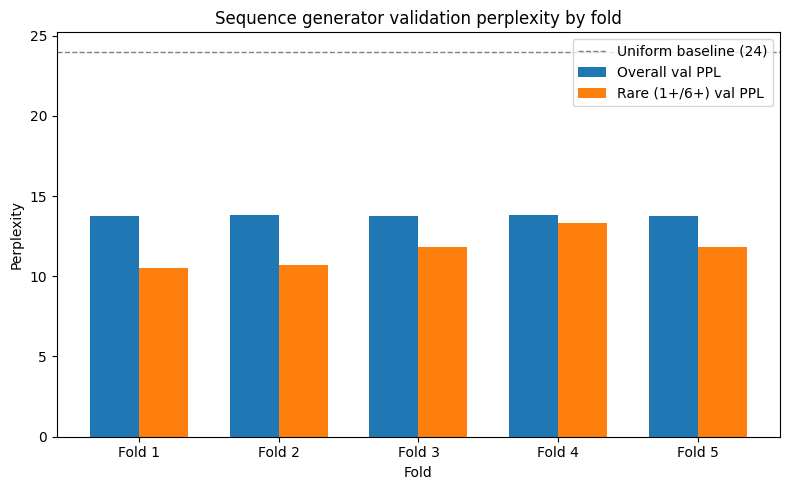

In [36]:
import matplotlib.pyplot as plt

x = np.arange(len(fold_metrics))
width = 0.35
overall_ppl = [m['overall_perplexity'] for m in fold_metrics]
rare_ppl = [m['rare_perplexity'] for m in fold_metrics]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, overall_ppl, width, label='Overall val PPL')
ax.bar(x + width/2, rare_ppl, width, label='Rare (1+/6+) val PPL')
ax.axhline(y=VOCAB_SIZE, color='gray', linestyle='--', linewidth=1, label=f'Uniform baseline ({VOCAB_SIZE})')
ax.set_xlabel('Fold'); ax.set_ylabel('Perplexity')
ax.set_title('Sequence generator validation perplexity by fold')
ax.set_xticks(x); ax.set_xticklabels([f"Fold {m['fold']}" for m in fold_metrics])
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/seq_gen_perplexity_by_fold.png", dpi=150)
plt.show()


In [37]:
def unigram_baseline(pairs_df, include_eos=True):
    from collections import Counter
    counts = Counter()
    total = 0
    for seq in pairs_df['peptide_sequence']:
        for tok in tokenize_peptide(seq):
            if tok in AA_DICT:
                counts[tok] += 1
                total += 1
        if include_eos:
            counts['<EOS>'] += 1
            total += 1
    avg_nll = -sum(c * np.log(c / total) for c in counts.values()) / total
    return {'avg_nll': avg_nll, 'perplexity': float(np.exp(avg_nll))}


In [38]:
SAVE_DIR = '/content/drive/MyDrive/my_proteomics_models'

real_1plus = splits['rare'][splits['rare']['precursor_charge'] == 1]['peptide_sequence'].unique().tolist()
real_6plus = splits['rare'][splits['rare']['precursor_charge'] == 6]['peptide_sequence'].unique().tolist()

gq_1 = generation_quality_metrics(new_1plus, known_seqs)
gq_6 = generation_quality_metrics(new_6plus, known_seqs)

unigram = unigram_baseline(all_df)

# Model vs. Baselines

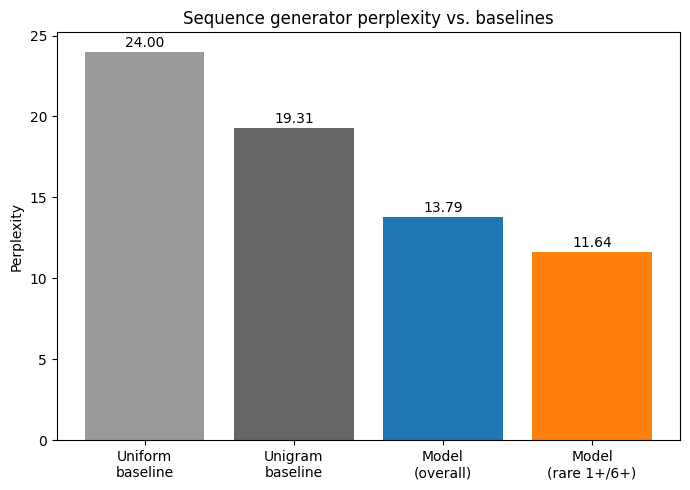

In [39]:
def plot_baseline_comparison(fold_metrics, uniform_ppl, unigram_ppl, save_path=None):
    avg_overall = np.mean([m['overall_perplexity'] for m in fold_metrics])
    avg_rare = np.mean([m['rare_perplexity'] for m in fold_metrics])

    labels = ['Uniform\nbaseline', 'Unigram\nbaseline', 'Model\n(overall)', 'Model\n(rare 1+/6+)']
    values = [uniform_ppl, unigram_ppl, avg_overall, avg_rare]
    colors = ['#999999', '#666666', '#1f77b4', '#ff7f0e']

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(labels, values, color=colors)
    ax.set_ylabel('Perplexity')
    ax.set_title('Sequence generator perplexity vs. baselines')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.2f}', ha='center')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_baseline_comparison(fold_metrics, VOCAB_SIZE, unigram['perplexity'],
                          save_path=f"{SAVE_DIR}/baseline_comparison.png")

# Sequence Quality

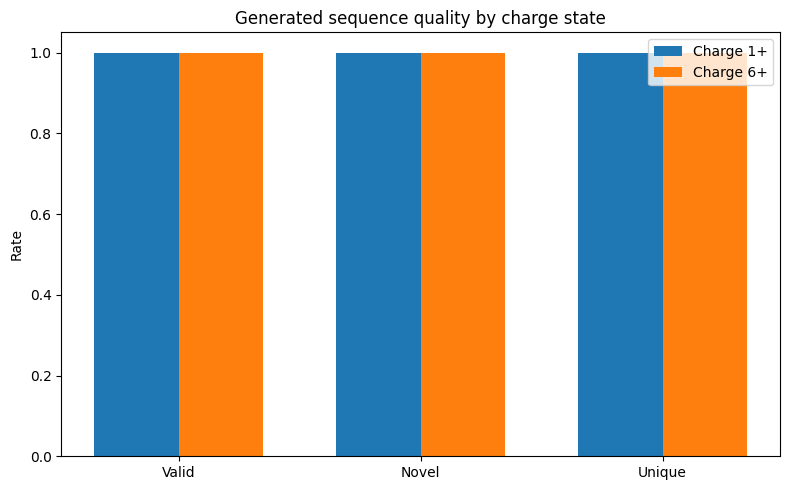

In [40]:
def plot_generation_quality(gq_1, gq_6, save_path=None):
    metrics = ['valid_rate', 'novel_rate', 'unique_rate']
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - width/2, [gq_1[m] for m in metrics], width, label='Charge 1+')
    ax.bar(x + width/2, [gq_6[m] for m in metrics], width, label='Charge 6+')
    ax.set_xticks(x); ax.set_xticklabels(['Valid', 'Novel', 'Unique'])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Rate')
    ax.set_title('Generated sequence quality by charge state')
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_generation_quality(gq_1, gq_6, save_path=f"{SAVE_DIR}/generation_quality.png")

# AA Composition

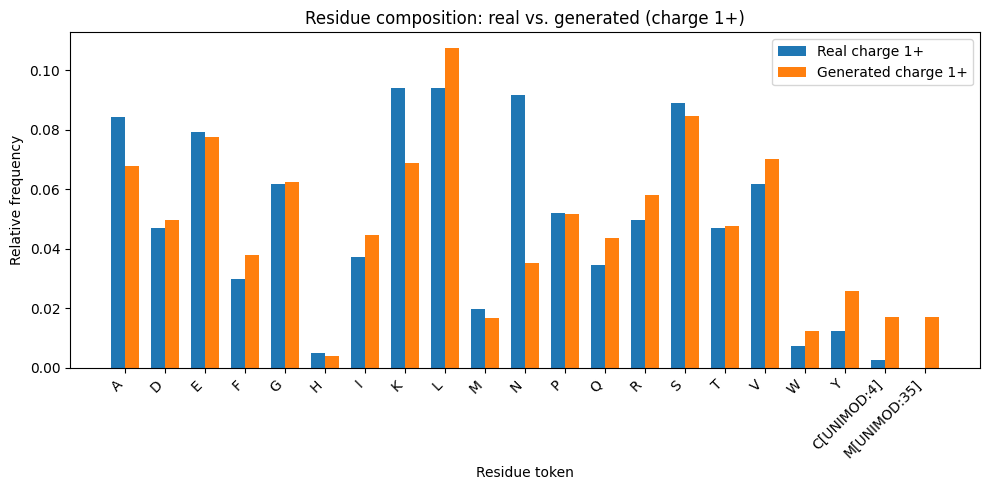

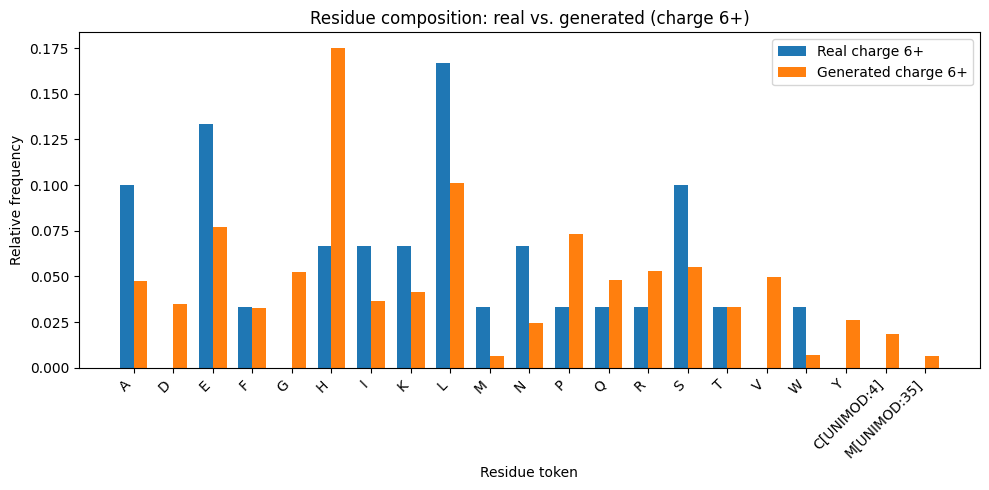

In [41]:
def plot_aa_composition(generated_seqs, real_seqs, charge_label, save_path=None):
    gen_freq = aa_frequency_vector(generated_seqs)
    real_freq = aa_frequency_vector(real_seqs)
    aa_order = list(AA_DICT.keys())

    x = np.arange(len(aa_order))
    width = 0.35
    fig, ax = plt.subplots(figsize=(max(10, 0.45 * len(aa_order)), 5))
    ax.bar(x - width/2, real_freq, width, label=f'Real charge {charge_label}+')
    ax.bar(x + width/2, gen_freq, width, label=f'Generated charge {charge_label}+')
    ax.set_xticks(x); ax.set_xticklabels(aa_order, rotation=45, ha='right')
    ax.set_xlabel('Residue token'); ax.set_ylabel('Relative frequency')
    ax.set_title(f'Residue composition: real vs. generated (charge {charge_label}+)')
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_aa_composition(new_1plus, real_1plus, charge_label=1, save_path=f"{SAVE_DIR}/aa_comp_charge1.png")
plot_aa_composition(new_6plus, real_6plus, charge_label=6, save_path=f"{SAVE_DIR}/aa_comp_charge6.png")


# Sequence Length Distribution

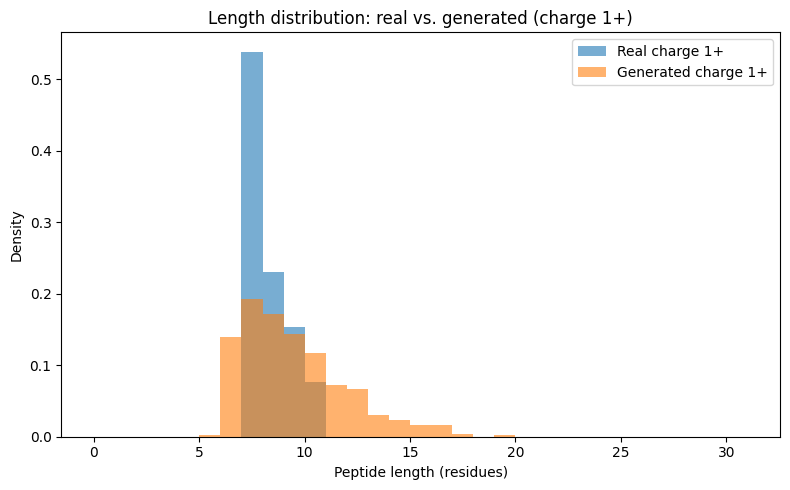

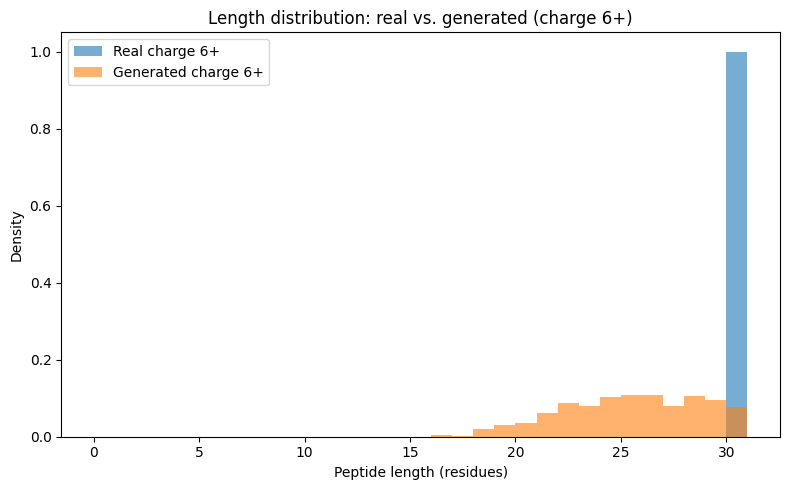

In [42]:
def plot_length_distribution(generated_seqs, real_seqs, charge_label, save_path=None):
    gen_lens = [len(tokenize_peptide(s)) for s in generated_seqs]
    real_lens = [len(tokenize_peptide(s)) for s in real_seqs]
    bins = np.arange(0, 32, 1)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(real_lens, bins=bins, alpha=0.6, label=f'Real charge {charge_label}+', density=True)
    ax.hist(gen_lens, bins=bins, alpha=0.6, label=f'Generated charge {charge_label}+', density=True)
    ax.set_xlabel('Peptide length (residues)'); ax.set_ylabel('Density')
    ax.set_title(f'Length distribution: real vs. generated (charge {charge_label}+)')
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

plot_length_distribution(new_1plus, real_1plus, charge_label=1, save_path=f"{SAVE_DIR}/length_dist_charge1.png")
plot_length_distribution(new_6plus, real_6plus, charge_label=6, save_path=f"{SAVE_DIR}/length_dist_charge6.png")
